In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

from utils.parser_utils import save_conllu_by_sent_id
from IPython.display import display_svg


sns.set_theme(style="whitegrid")
so.Plot.config.display["format"] = "svg"
pd.options.mode.chained_assignment = None

ud_data_path = "diaparser/ud_test.conllu"

In [2]:
# Import the data
data = pd.read_csv('results.csv')
data['ellipsis'] = data['ellipsis'] == 1

In [3]:
heads = data.drop(columns=['ud_test_deprel', 'ud_preds_deprel', 'str_test_deprel', 'str_preds_deprel'])

deprels = data.drop(columns=['ud_test_head', 'ud_preds_head', 'str_test_head', 'str_preds_head'])
deprels = deprels.rename(columns={'ud_test_deprel': 'ud_test', 'ud_preds_deprel': 'ud_pred', 'str_test_deprel': 'str_test', 'str_preds_deprel': 'str_pred'})

In [4]:
# Create dataframe where ud was wrong but str was correct
mismatches = deprels[(deprels['ud_test'] != deprels['ud_pred']) & (deprels['str_test'] == deprels['str_pred'])]
all = deprels[deprels['str_test'] == deprels['str_pred']]

In [5]:
# Calculate the most frequent mismatches in dependency relations relative to the predcitions
mismatch_count = mismatches.groupby(['ud_pred', 'str_test']).size().reset_index(name='count')
all_count = all.groupby(['ud_pred', 'str_test']).size().reset_index(name='count')

preds_count = pd.merge(mismatch_count, all_count, on=['ud_pred', 'str_test'], suffixes=('_mismatch', '_all'))
preds_count['frequency'] = (preds_count['count_mismatch'] / preds_count['count_all'] * 100).round(decimals=2)
preds_count = preds_count.drop(columns=['count_all']).rename(columns={'count_mismatch': 'count'})

preds_count = preds_count[(preds_count['count'] > 10) & (preds_count['frequency'] > 50)] # count and frequency thresholds
preds_count = preds_count.sort_values(['frequency', 'count'], ascending=[False, False]).reset_index(drop=True)

preds_count['ud_golds'] = preds_count.apply(lambda row: deprels[(deprels['ud_pred'] == row['ud_pred']) & (deprels['str_test'] == row['str_test'])]['ud_test'].value_counts().index[:3].tolist(), axis=1)
preds_count['ud_golds'] = preds_count['ud_golds'].apply(lambda x: ',   '.join(x))
preds_count = preds_count.rename(columns={'str_test': 'str_gold'})

preds_count.head(15)

,ud_pred,str_gold,count,frequency,ud_golds
0,root,предик,15,93.75,"nsubj, csubj, root"
1,nsubj,1-компл,19,86.36,"obj, obl, nsubj"
2,obl:tmod,обст,18,72.00,"obl, obl:tmod, advmod"
3,xcomp,присвяз,22,62.86,"obl, xcomp"


In [6]:
# Calculate the most frequent mismatches in dependency relations relative to the gold standard
mismatch_count = mismatches.groupby(['ud_test', 'str_test']).size().reset_index(name='count')
all_count = all.groupby(['ud_test', 'str_test']).size().reset_index(name='count')

gold_count = pd.merge(mismatch_count, all_count, on=['ud_test', 'str_test'], suffixes=('_mismatch', '_all'))
gold_count['frequency'] = (gold_count['count_mismatch'] / gold_count['count_all'] * 100).round(decimals=2)
gold_count = gold_count.drop(columns=['count_all']).rename(columns={'count_mismatch': 'count'})

gold_count = gold_count[(gold_count['count'] > 20) & (gold_count['frequency'] > 50)] # count and frequency thresholds
gold_count = gold_count.sort_values(['count', 'frequency'], ascending=[False, False]).reset_index(drop=True)
# Add column with three most probable ud_test_deprel standarts (not including predicted) for this ud_preds_deprel and str_test_deprel
gold_count['ud_preds'] = gold_count.apply(lambda row: deprels[(deprels['ud_test'] == row['ud_test']) & (deprels['str_test'] == row['str_test'])]['ud_pred'].value_counts().index[:3].tolist(), axis=1)
gold_count['ud_preds'] = gold_count['ud_preds'].apply(lambda x: ',   '.join(x))
gold_count = gold_count.rename(columns={'ud_test': 'ud_gold', 'str_test': 'str_gold'})
gold_count.head(15)

,ud_gold,str_gold,count,frequency,ud_preds
0,xcomp,присвяз,80,86.02,"obl, xcomp, advmod"
1,case,сравнит,66,100.00,mark
2,acl,1-компл,45,91.84,"obl, acl, nmod"
3,obl:agent,агент,38,100.00,obl
4,obl:tmod,обст,34,82.93,"obl, obl:tmod, parataxis"
5,iobj,обст,25,92.59,"obl, iobj, nsubj"
6,obl:tmod,длительн,25,83.33,"obl, obl:tmod, nummod:gov"
7,mark,огранич,24,96.00,"cc, mark, advmod"
8,appos,примыкат,21,77.78,"parataxis, appos"


In [7]:
# Create dataframe with the most frequent mismatches
top_groups = []
for i in range(9):
    group = gold_count.iloc[i]
    ud_test_deprel = group['ud_gold']
    ud_preds_deprel = group['ud_preds']
    str_test_deprel = group['str_gold']
    top_groups.append(mismatches[(mismatches['ud_test'] == ud_test_deprel) & (mismatches['str_test'] == str_test_deprel)])

#### Связь `присвяз` и ошибка `obl -> xcomp`:
* В случае конструкций с составным именным сказуемым, все глаголы-связки за исключением "быть" принято решение использовать отношение `xcomp`, что не всегда выполняется для предложений после конвертации:

* *Note: Эта ошибка характерна для старой части корпуса, в версии после 2015-го года таких ошибок мало или нет*

* Пример неправильного присваивания `obl` вместо `xcomp`:
  

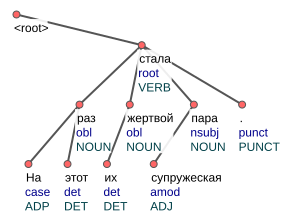

In [35]:
save_conllu_by_sent_id(ud_data_path, "3_newsYa_94", "examples/1.conllu")
svg_data = open("examples/1.svg", "r", encoding="utf-8").read()
display_svg(svg_data, raw=True)

#### Связь `сравнит` и ошибка `mark -> case/obl`:

* Синтаксическая связь `сравнит` вводит вторую часть сравнительной конструкции и в UD в таких случаях на сравнительный союз должна идти связь `case`, в случае сравнительного союза "чем", или связь `obl` в остальных случаях. В любом из двух случаев, присвоение союзу отношения `mark` является ошибкой.

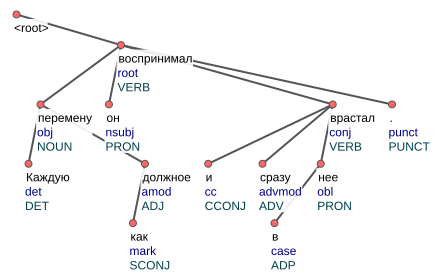

In [67]:
# save_conllu_by_sent_id(ud_data_path, "100_uppsalaGrekova_2", "examples/2.conllu")
svg_data = open("examples/2.svg", "r", encoding="utf-8").read()
display_svg(svg_data, raw=True)

#### Группа ошибок неуточнённой связи `obl`:

* Включает в себя случаи, когда было присвоено отношение `obl` в тех случаях, где правильным было бы присвоить его существующее уточнение, специфичное для UD русского языка, например `obl:agent` и `obl:tmod`.

* Пример неуточнённой связи `obl` вместо `obl:tmod`:

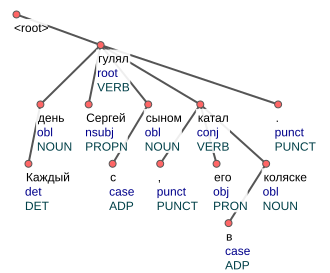

In [129]:
# save_conllu_by_sent_id(ud_data_path, "86_uppsalaBitov_1", "examples/3_1.conllu")
svg_data = open("examples/3_1.svg", "r", encoding="utf-8").read()
display_svg(svg_data, raw=True)

* Пример неуточнённой связи `obl` вместо `obl:agent`:

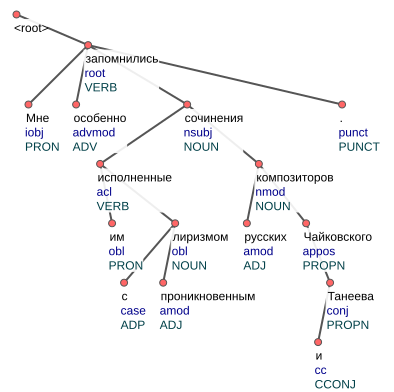

In [136]:
save_conllu_by_sent_id(ud_data_path, "11_2005Tokarskaya", "examples/3_2.conllu")
svg_data = open("examples/3_2.svg", "r", encoding="utf-8").read()
display_svg(svg_data, raw=True)

In [ ]:
test = deprels[(deprels['ud_test'] == 'cc') & (deprels['str_test'] == 'огранич')]
test.shape[0]

In [ ]:
for i, row in test[4:].head(4).iterrows():
    print(f"Word: {row['word']}")
    print("Sent id:", row['sent_id'])
    print(f"Text: {row['text']}")
    print(f"UD: {row['ud_pred']} -> {row['ud_test']}")
    print(f"STR: {row['str_pred']} -> {row['str_test']}")
    print()